# ViSoBERT - Pretrained

**Model**: `uitnlp/visobert`

**Workflow**: Text → BERT → Embedding (768d) → PCA → LogReg → 5-Fold CV

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Data

In [2]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'encoded' / 'final_data_shuffled.csv')
texts = df['text_bert'].fillna('').tolist()
labels = df['label'].values
print(f"Samples: {len(texts)}, Labels: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Labels: {0: 3929, 1: 807}


## 2. Load Model & Extract Embeddings

In [3]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'uitnlp/visobert'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print(f"Loaded {MODEL_NAME}, hidden_size={model.config.hidden_size}")

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded uitnlp/visobert, hidden_size=768


In [4]:
def extract_embeddings(texts, tokenizer, model, device, max_length=256, batch_size=16):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting"):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
            out = model(input_ids=enc['input_ids'].to(device), attention_mask=enc['attention_mask'].to(device))
            embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeddings)

embeddings = extract_embeddings(texts, tokenizer, model, DEVICE)
print(f"Embeddings: {embeddings.shape}")

del model; torch.cuda.empty_cache()

Extracting: 100%|██████████| 296/296 [01:07<00:00,  4.37it/s]

Embeddings: (4736, 768)


## 3. Evaluation Function

In [5]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def evaluate_dim(X, y, dim):
    if dim < X.shape[1]:
        pca = PCA(n_components=dim, random_state=42)
        X_r = pca.fit_transform(X)
        var = pca.explained_variance_ratio_.sum()
    else:
        X_r, var = X.copy(), 1.0
    X_s = StandardScaler().fit_transform(X_r)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(clf, X_s, y, cv=cv, scoring='roc_auc')
    f1 = cross_val_score(clf, X_s, y, cv=cv, scoring='f1')
    prec = cross_val_score(clf, X_s, y, cv=cv, scoring='precision')
    rec = cross_val_score(clf, X_s, y, cv=cv, scoring='recall')
    return {'dim': dim, 'var': var,
            'auc_mean': auc.mean(), 'auc_std': auc.std(),
            'f1_mean': f1.mean(), 'f1_std': f1.std(),
            'prec_mean': prec.mean(), 'prec_std': prec.std(),
            'rec_mean': rec.mean(), 'rec_std': rec.std()}

def plot_metrics(df_results, title_prefix, x_col='dim'):
    metrics = [('auc', 'AUC-ROC'), ('f1', 'F1'), ('prec', 'Precision'), ('rec', 'Recall')]
    df_plot = df_results.sort_values(x_col)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (m, name) in zip(axes.flat, metrics):
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3)
        ax.set_xlabel('Dimension'); ax.set_ylabel(name)
        ax.set_title(f'{title_prefix} - {name}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, name in metrics:
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3, label=name)
    ax.set_xlabel('Dimension'); ax.set_ylabel('Score')
    ax.set_title(f'{title_prefix} - All Metrics', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 4. Coarse Search (Step=100)

In [6]:
COARSE_DIMS = [768, 668, 568, 468, 368, 268, 168, 68]

coarse_results = []
for dim in tqdm(COARSE_DIMS, desc="Coarse Search"):
    r = evaluate_dim(embeddings, labels, dim)
    coarse_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}")

df_coarse = pd.DataFrame(coarse_results)
best_coarse = df_coarse.loc[df_coarse['auc_mean'].idxmax()]
print(f"\nBest coarse: dim={int(best_coarse['dim'])}, AUC={best_coarse['auc_mean']:.4f}")

Coarse Search:  12%|█▎        | 1/8 [00:07<00:51,  7.32s/it]

Dim  768: AUC=0.8360, F1=0.5553, Prec=0.4736, Rec=0.6715


Coarse Search:  25%|██▌       | 2/8 [00:09<00:26,  4.41s/it]

Dim  668: AUC=0.8164, F1=0.5303, Prec=0.4512, Rec=0.6442


Coarse Search:  38%|███▊      | 3/8 [00:11<00:16,  3.33s/it]

...

Dim  268: AUC=0.8627, F1=0.5676, Prec=0.4549, Rec=0.7559


Coarse Search:  88%|████████▊ | 7/8 [00:17<00:01,  1.55s/it]

Dim  168: AUC=0.8706, F1=0.5811, Prec=0.4609, Rec=0.7869


Coarse Search: 100%|██████████| 8/8 [00:17<00:00,  2.19s/it]

Dim   68: AUC=0.8644, F1=0.5608, Prec=0.4350, Rec=0.7906

Best coarse: dim=168, AUC=0.8706


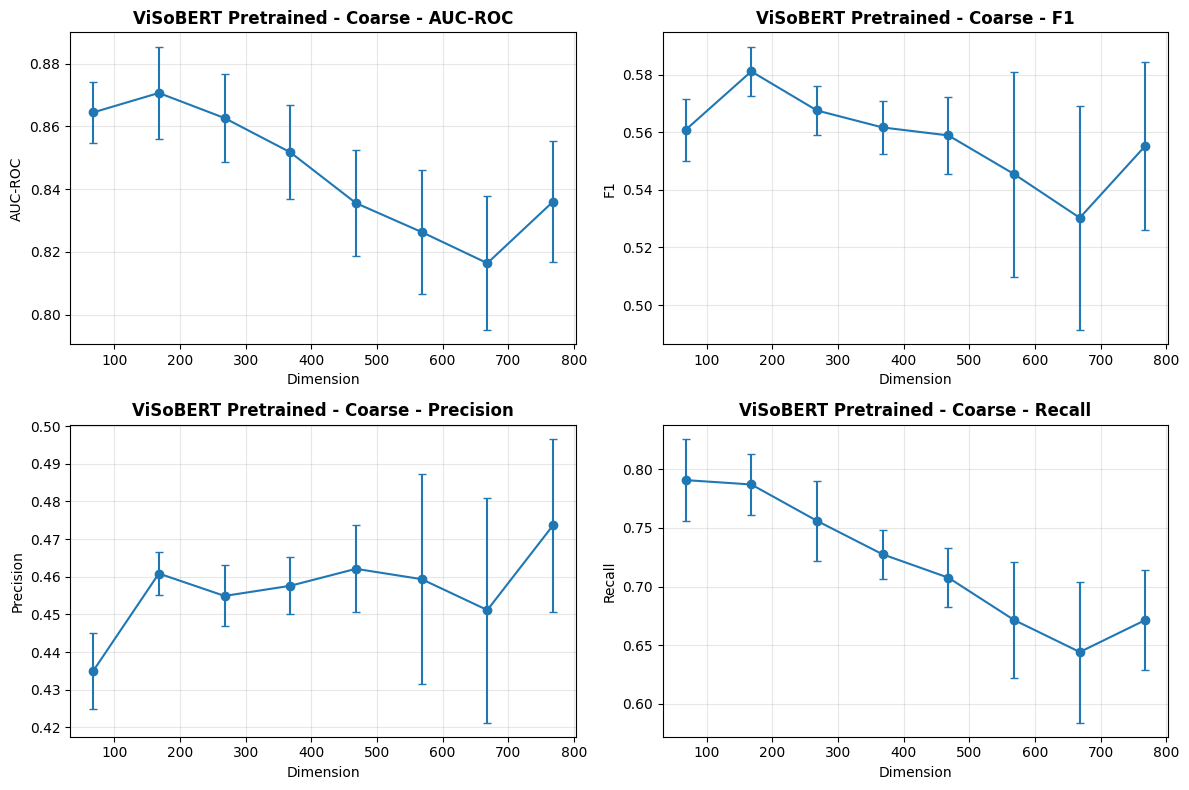

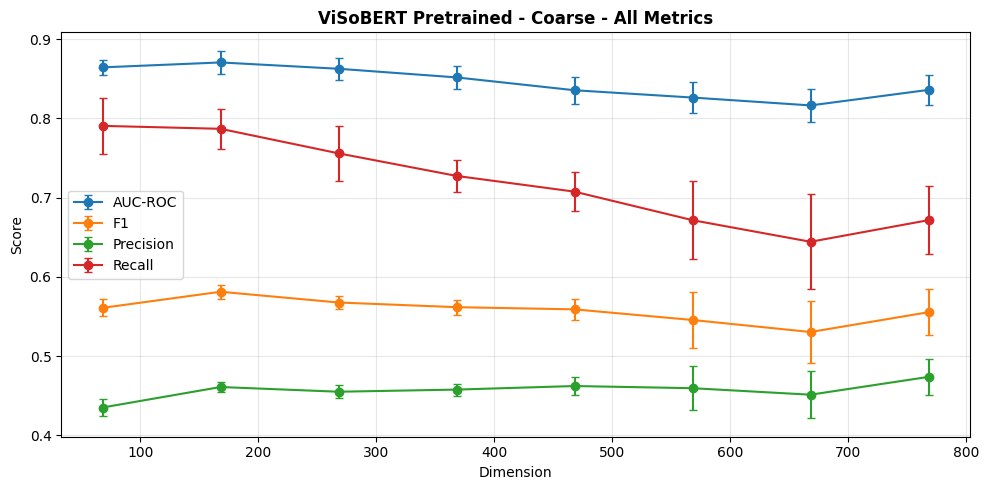

In [7]:
plot_metrics(df_coarse, 'ViSoBERT Pretrained - Coarse')

## 5. Fine Search (Step=10)

In [8]:
best_dim = int(best_coarse['dim'])
fine_start = max(68, best_dim - 50)
fine_end = min(768, best_dim + 50)
FINE_DIMS = list(range(fine_start, fine_end + 1, 10))
print(f"Fine search range: {fine_start} to {fine_end}, dims: {FINE_DIMS}")

fine_results = []
for dim in tqdm(FINE_DIMS, desc="Fine Search"):
    r = evaluate_dim(embeddings, labels, dim)
    fine_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}")

df_fine = pd.DataFrame(fine_results)
best_fine = df_fine.loc[df_fine['auc_mean'].idxmax()]
print(f"\nBest fine: dim={int(best_fine['dim'])}, AUC={best_fine['auc_mean']:.4f}")

Fine search range: 118 to 218, dims: [118, 128, 138, 148, 158, 168, 178, 188, 198, 208, 218]


Fine Search:   9%|▉         | 1/11 [00:00<00:05,  1.82it/s]

Dim  118: AUC=0.8709, F1=0.5727, Prec=0.4522, Rec=0.7819


Fine Search:  18%|█▊        | 2/11 [00:01<00:04,  1.91it/s]

Dim  128: AUC=0.8688, F1=0.5649, Prec=0.4441, Rec=0.7770


...

Dim  198: AUC=0.8705, F1=0.5818, Prec=0.4618, Rec=0.7868


Fine Search:  91%|█████████ | 10/11 [00:07<00:00,  1.19it/s]

Dim  208: AUC=0.8680, F1=0.5761, Prec=0.4568, Rec=0.7806


Fine Search: 100%|██████████| 11/11 [00:08<00:00,  1.33it/s]

Dim  218: AUC=0.8684, F1=0.5833, Prec=0.4664, Rec=0.7794

Best fine: dim=178, AUC=0.8719


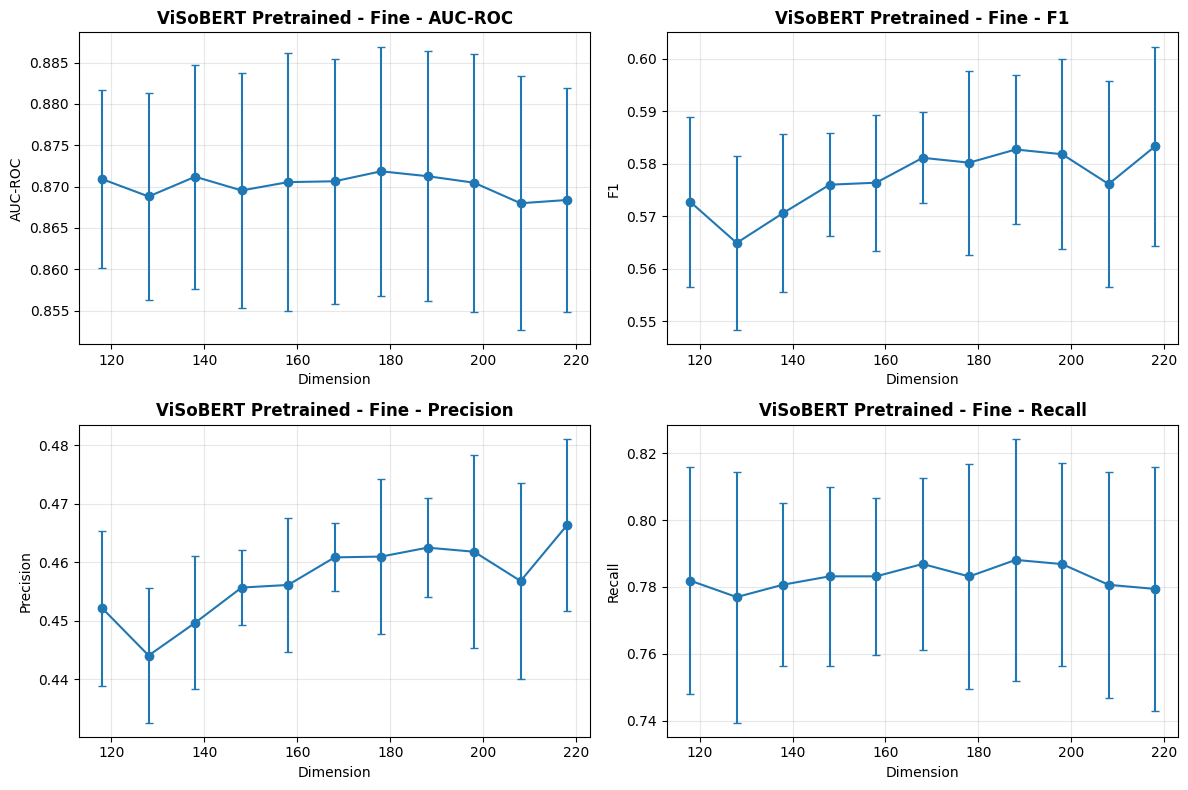

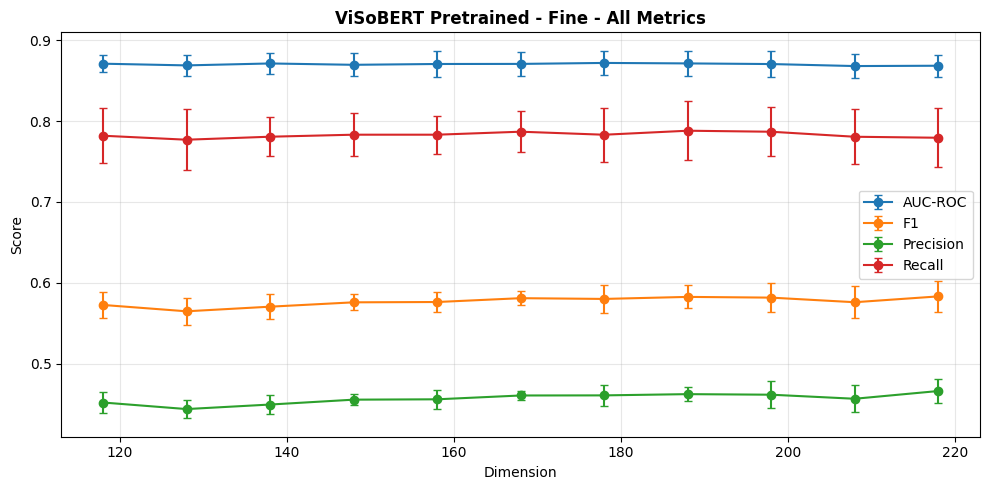

In [9]:
plot_metrics(df_fine, 'ViSoBERT Pretrained - Fine')

## 6. Final Results

In [10]:
OPTIMAL_DIM = int(best_fine['dim'])
print("="*70)
print(f"VISOBERT PRETRAINED - OPTIMAL DIM: {OPTIMAL_DIM}")
print("="*70)
print(f"AUC:       {best_fine['auc_mean']:.4f} ± {best_fine['auc_std']:.4f}")
print(f"F1:        {best_fine['f1_mean']:.4f} ± {best_fine['f1_std']:.4f}")
print(f"Precision: {best_fine['prec_mean']:.4f} ± {best_fine['prec_std']:.4f}")
print(f"Recall:    {best_fine['rec_mean']:.4f} ± {best_fine['rec_std']:.4f}")
print(f"Variance:  {best_fine['var']:.2%}")

VISOBERT PRETRAINED - OPTIMAL DIM: 178
AUC:       0.8719 ± 0.0151
F1:        0.5802 ± 0.0175
Precision: 0.4610 ± 0.0132
Recall:    0.7831 ± 0.0335
Variance:  94.19%


## 7. Save Optimal Embeddings

In [11]:
pca = PCA(n_components=OPTIMAL_DIM, random_state=42)
embeddings_optimal = pca.fit_transform(embeddings)
print(f"Reduced embeddings: {embeddings_optimal.shape}")

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'encoded' / 'visobert'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.save(OUTPUT_DIR / 'pretrained_embeddings.npy', embeddings_optimal)
print(f"Saved to {OUTPUT_DIR / 'pretrained_embeddings.npy'}")
print(f"Shape: {embeddings_optimal.shape} (matches {len(df)} rows in final_data_shuffled.csv)")

Reduced embeddings: (4736, 178)
Saved to d:\Vietnamese-Fake-News-Detection\data\encoded\visobert\pretrained_embeddings.npy
Shape: (4736, 178) (matches 4736 rows in final_data_shuffled.csv)
